In [1]:
import torch
import torchaudio
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from omegaconf import OmegaConf
from torch.utils.data import DataLoader

from src.synths.synth import Synth, SynthConfig
from src.synths.ddsp import Implementation
from src.decoder import KSDecoder
from src.model import SoundMatchingModel
from src.data.nsynth.nsynth_guitar_dataset import NsynthGuitarDataset
from src.detectors import run_detectors_on_batch

import os
os.chdir("/Users/pablotablasdepaula/PycharmProjects/DAFx26-Karplus")

# =============================================================================
# 1. CONFIGURATION
# =============================================================================
FS = 16000
DURATION = 4.0
NUM_SAMPLES = int(FS * DURATION)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_DIR = Path("experiments/checkpoints")

SAMPLE_IDX = 43 # <-- change this to pick a different NSynth sample

# --- FIGURE & LABEL CONFIGURATION ---
FIG_WIDTH = 6.0
FIG_HEIGHT = 8.0
LABEL_FONTSIZE = 11
Y_LABEL_X_POS = 0.04
CBAR_X_POS = 0.92
H_SPACE = 0.22

# --- MEL SPECTROGRAM ---
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=FS,
    n_fft=528,
    hop_length=256,
    n_mels=128,
    f_min=32.0,
    f_max=8000.0,
    norm="slaney",
    mel_scale="slaney"
).to(DEVICE)

def get_log_mel(audio_tensor):
    if audio_tensor.ndim == 2:
        audio_tensor = audio_tensor.squeeze(0)
    mel = mel_transform(audio_tensor.to(DEVICE))
    log_mel = torch.log10(mel + 1e-9)
    return log_mel.cpu().numpy()

# =============================================================================
# 2. LOAD NSYNTH SAMPLE
# =============================================================================
ds = NsynthGuitarDataset(nsynth_root="src/data/nsynth", split="test")
sample = ds[SAMPLE_IDX]
tgt_audio = sample["audio"].unsqueeze(0).to(DEVICE)  # [1, N]
print(f"Loaded NSynth sample {SAMPLE_IDX}, shape: {tgt_audio.shape}")

# =============================================================================
# 3. HELPER: LOAD MODEL FROM CHECKPOINT
# =============================================================================
IMPL_MAP = {
    "time_domain": Implementation.TIME_DOMAIN,
    "frequency_sampling": Implementation.FREQUENCY_SAMPLING,
    "oracle": Implementation.TIME_DOMAIN,
}

def load_model(tag: str):
    """Find latest checkpoint for tag, load model."""
    valid = []
    for ckpt in CKPT_DIR.glob(f"{tag}*best.ckpt"):
        cfg_path = CKPT_DIR / ckpt.name.replace("_best.ckpt", "_config.yaml")
        if cfg_path.exists():
            valid.append((ckpt, cfg_path))
    assert valid, f"No checkpoint found for {tag}"
    valid.sort(key=lambda x: x[0].name)
    ckpt_path, cfg_path = valid[-1]
    print(f"  Loading: {ckpt_path.name}")

    cfg = OmegaConf.load(cfg_path)
    synth = Synth(SynthConfig(
        num_samples=cfg.num_audio_samples, fs=cfg.fs,
        implementation=IMPL_MAP[cfg.model.implementation],
        lagrange_order=cfg.model.synth.lagrange_order,
        n_fft=cfg.model.synth.n_fft,
        hop_length=cfg.model.synth.hop_length,
    ))
    decoder = KSDecoder(synth=synth, use_external_detectors=cfg.detector.use_external_detectors)
    model = SoundMatchingModel(
        decoder=decoder,
        encoder_kwargs=OmegaConf.to_container(cfg.model.encoder, resolve=True),
    )
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    state_dict = {k.replace("model.", "", 1): v for k, v in ckpt["state_dict"].items() if k.startswith("model.")}
    model.load_state_dict(state_dict)
    return model.to(DEVICE).eval()

# =============================================================================
# 4. LOAD MODELS & RUN INFERENCE
# =============================================================================
print("\n--- Loading tKSA Audio-Only (real) ---")
model_t = load_model("tKSA_xDet_real")

print("\n--- Loading fKSA Audio-Only (real) ---")
model_f = load_model("fKSA_xDet_real")

with torch.inference_mode():
    # Run external detectors (shared for both models)
    detected = run_detectors_on_batch(tgt_audio, sr=FS, num_frames=250)
    detected = {k: v.to(DEVICE) for k, v in detected.items()}

    # tKSA inference
    raw_t = model_t.encoder(tgt_audio)
    params_t = model_t.decoder.activate(raw_t, detected=detected)
    audio_t, _ = model_t.decoder.oracle_synth(params_t)

    # fKSA inference
    raw_f = model_f.encoder(tgt_audio)
    params_f = model_f.decoder.activate(raw_f, detected=detected)
    audio_f, _ = model_f.decoder.oracle_synth(params_f)

    # fKSA training path (frequency-sampling forward, shows aliasing)
    audio_f_train, _ = model_f.decoder.synthesise(params_f)

print("\nInference complete.")

Loaded NSynth sample 43, shape: torch.Size([1, 64000])

--- Loading tKSA Audio-Only (real) ---
  Loading: tKSA_xDet_real_20260323_224936_best.ckpt

--- Loading fKSA Audio-Only (real) ---
  Loading: fKSA_xDet_real_20260323_213533_best.ckpt


/Users/pablotablasdepaula/PycharmProjects/DAFx26-Karplus/.pixi/envs/default/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)



Inference complete.


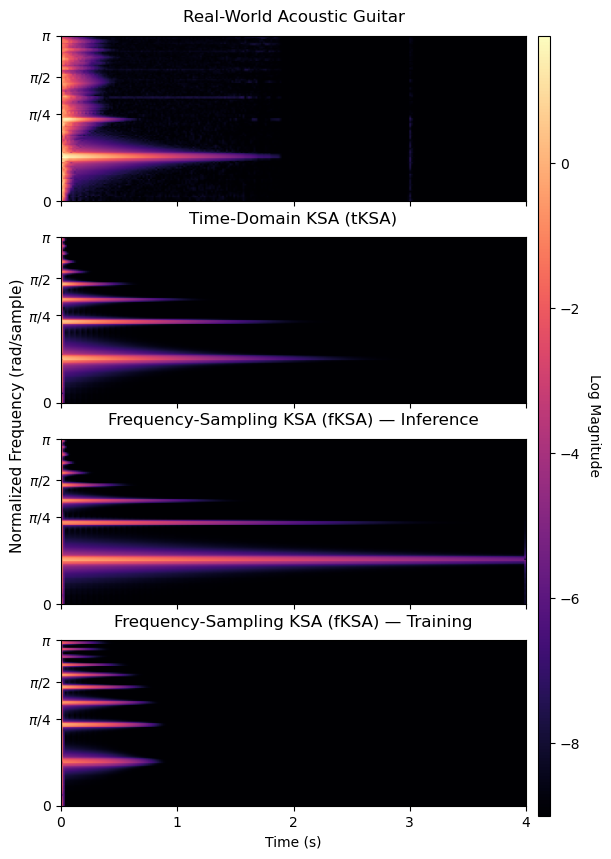

In [2]:
# =============================================================================
# 5. FIGURE 1: NSynth Target vs tKSA vs fKSA (inference + training)
# =============================================================================
spec_tgt = get_log_mel(tgt_audio)
spec_t = get_log_mel(audio_t)
spec_f = get_log_mel(audio_f)
spec_f_train = get_log_mel(audio_f_train)

fig, axes = plt.subplots(4, 1, figsize=(FIG_WIDTH, 10.0), sharex=True, sharey=True)
fig.subplots_adjust(hspace=H_SPACE)

specs = [
    (spec_tgt,     "Real-World Acoustic Guitar"),
    (spec_t,       "Time-Domain KSA (tKSA)"),
    (spec_f,       "Frequency-Sampling KSA (fKSA) — Inference"),
    (spec_f_train, "Frequency-Sampling KSA (fKSA) — Training"),
]

vmax = max(s.max() for s, _ in specs)
vmin = min(s.min() for s, _ in specs)

# Frequency axis: Mel bins → normalised frequency labels
f_min, f_max = 32.0, 8000.0
def hz_to_mel(hz):
    return 2595.0 * np.log10(1.0 + hz / 700.0)

m_min, m_max = hz_to_mel(f_min), hz_to_mel(f_max)
norm_freq_ticks = np.array([0.0, 0.25, 0.5, 1.0])
hz_ticks = norm_freq_ticks * f_max
mel_ticks = hz_to_mel(hz_ticks)
bin_ticks = 128 * (mel_ticks - m_min) / (m_max - m_min)
bin_ticks[0] = 0
pi_labels = ["0", r"$\pi/4$", r"$\pi/2$", r"$\pi$"]

fig.supylabel("Normalized Frequency (rad/sample)", fontsize=LABEL_FONTSIZE, x=Y_LABEL_X_POS)

for ax, (spec, title) in zip(axes, specs):
    im = ax.imshow(
        np.clip(spec, vmin, vmax), origin='lower', aspect='auto', cmap='magma',
        extent=[0, DURATION, 0, 128], vmin=vmin, vmax=vmax,
    )
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_yticks(bin_ticks)
    ax.set_yticklabels(pi_labels)

axes[-1].set_xlabel("Time (s)", fontsize=10)
axes[-1].set_xticks([0, 1, 2, 3, 4])

cbar_ax = fig.add_axes([CBAR_X_POS, 0.10, 0.02, 0.78])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Log Magnitude', rotation=270, labelpad=15)

plt.savefig("figures/nsynth_tKSA_vs_fKSA.pdf", bbox_inches='tight')
plt.show()


In [3]:
import IPython.display as ipd
from IPython.display import display

print("NSynth Target")
display(ipd.Audio(tgt_audio.squeeze().cpu().numpy(), rate=FS))

print("tKSA (Audio-Only)")
display(ipd.Audio(audio_t.squeeze().cpu().numpy(), rate=FS))

print("fKSA — Inference")
display(ipd.Audio(audio_f.squeeze().cpu().numpy(), rate=FS))

print("fKSA — Training")
display(ipd.Audio(audio_f_train.squeeze().cpu().numpy(), rate=FS))


NSynth Target


tKSA (Audio-Only)


fKSA — Inference


fKSA — Training
